# 02 — EGFR Bioactivity Data Preprocessing

## Objective

Clean and consolidate experimentally measured EGFR IC50 data into a
molecule-level dataset suitable for QSAR machine-learning analysis.

## Main preprocessing steps

1. Load filtered ChEMBL IC50 data
2. Remove invalid or questionable measurements
3. Assess repeated measurements per compound
4. Retrieve molecular structures
5. Consolidate repeated IC50 measurements
6. Calculate pIC50
7. Define activity classes
8. Save the ML-ready dataset

### Imports and paths

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

input_path = RAW_DATA_DIR / "egfr_ic50_filtered_raw.csv"

### Load the dataset

In [3]:
df = pd.read_csv(input_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (18381, 47)


/var/folders/dt/g2rs0x4s39n7sjnjnlbqvtt80000gn/T/ipykernel_92945/248817566.py:1: DtypeWarning: Columns (0: modality) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,NaN,NaN,32260,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.041
1,NaN,NaN,32267,[],CHEMBL674637,Inhibitory activity towards tyrosine phosphory...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,0.170
2,NaN,NaN,32680,[],CHEMBL677833,In vitro inhibition of Epidermal growth factor...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,9.300
3,NaN,NaN,32770,[],CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,500.000
4,NaN,NaN,32772,[],CHEMBL674643,Inhibitory concentration of EGF dependent auto...,B,NaN,NaN,BAO_0000190,...,Homo sapiens,Epidermal growth factor receptor,9606,NaN,NaN,IC50,uM,UO_0000065,NaN,3000.000


### Check the quality flags

In [4]:
df["data_validity_comment"].value_counts(dropna=False)

data_validity_comment
NaN                              18124
Outside typical range              199
Potential transcription error       58
Name: count, dtype: int64

In [5]:
df["potential_duplicate"].value_counts(dropna=False)

potential_duplicate
0    16285
1     2096
Name: count, dtype: int64

In [6]:
df["standard_value"].isna().sum()

np.int64(1)

### Remove clearly problematic records

In [7]:
clean_df = df.copy()

clean_df = clean_df[
    clean_df["standard_value"].notna()
].copy()

clean_df = clean_df[
    clean_df["data_validity_comment"].isna()
].copy()

clean_df = clean_df[
    clean_df["potential_duplicate"] == 0
].copy()

print("Original records:", len(df))
print("Records after quality filtering:", len(clean_df))

Original records: 18381
Records after quality filtering: 16101


### Check how many unique molecules remain

In [8]:
n_measurements = len(clean_df)

n_unique_molecules = clean_df["molecule_chembl_id"].nunique()

print(f"Measurements remaining: {n_measurements:,}")
print(f"Unique molecules: {n_unique_molecules:,}")

Measurements remaining: 16,101
Unique molecules: 10,398


### See how many measurements each molecule has

In [9]:
measurements_per_molecule = (
    clean_df["molecule_chembl_id"]
    .value_counts()
)

measurements_per_molecule.describe()

count    10398.000000
mean         1.548471
std          2.017121
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         89.000000
Name: count, dtype: float64

In [10]:
measurements_per_molecule.head(20)

molecule_chembl_id
CHEMBL939        89
CHEMBL3353410    83
CHEMBL553        77
CHEMBL3545311    54
CHEMBL1173655    51
CHEMBL1229592    45
CHEMBL3545308    33
CHEMBL554        31
CHEMBL388978     29
CHEMBL3545154    23
CHEMBL1873475    21
CHEMBL31965      20
CHEMBL180022     20
CHEMBL29197      18
CHEMBL2011291    17
CHEMBL285063     16
CHEMBL24828      13
CHEMBL5095169    13
CHEMBL4650319    12
CHEMBL2110732    11
Name: count, dtype: int64

### Inspect repeated IC50 values

In [11]:
repeated_ids = measurements_per_molecule[
    measurements_per_molecule > 1
].index

repeated_df = clean_df[
    clean_df["molecule_chembl_id"].isin(repeated_ids)
].copy()

print("Molecules with repeated measurements:",
      len(repeated_ids))

Molecules with repeated measurements: 3127


In [12]:
repeated_df[
    [
        "molecule_chembl_id",
        "standard_value",
        "assay_chembl_id"
    ]
].sort_values(
    ["molecule_chembl_id", "standard_value"]
).head(30)

,molecule_chembl_id,standard_value,assay_chembl_id
17752,CHEMBL10,10000.00,CHEMBL6085285
630,CHEMBL10,96000.00,CHEMBL672267
885,CHEMBL105436,300.00,CHEMBL674015
886,CHEMBL105436,10000.00,CHEMBL674012
12292,CHEMBL1079742,2.00,CHEMBL5512964
3065,CHEMBL1079742,15.00,CHEMBL1116653
8716,CHEMBL1079742,70.00,CHEMBL4273762
3061,CHEMBL1079742,420.00,CHEMBL1116652
3064,CHEMBL1080506,5000.00,CHEMBL1116653
3056,CHEMBL1080506,12650.00,CHEMBL1116652


## Consolidate Repeated IC50 Measurements

Multiple experimental IC50 measurements were available for some compounds. To create one activity value per molecule for machine-learning analysis repeated measurements were consolidated using the median IC50.

The median was selected because it is less sensitive to unusually high or low experimental measurements than the arithmetic mean.

### Calculate one medican IC50 per molecule

In [14]:
molecule_activity = (
    clean_df
    .groupby("molecule_chembl_id")
    .agg(
        median_ic50_nM=("standard_value", "median"),
        n_measurements=("standard_value", "count"),
        min_ic50_nM=("standard_value", "min"),
        max_ic50_nM=("standard_value", "max")
    )
    .reset_index()
)

print("Molecule-level dataset shape:", molecule_activity.shape)

molecule_activity.head(10)

Molecule-level dataset shape: (10398, 5)


,molecule_chembl_id,median_ic50_nM,n_measurements,min_ic50_nM,max_ic50_nM
0,CHEMBL10,53000.0,2,10000.0,96000.0
1,CHEMBL1009,2880.0,1,2880.0,2880.0
2,CHEMBL101253,457.7,1,457.7,457.7
3,CHEMBL1016,3276.9,1,3276.9,3276.9
4,CHEMBL101683,7300.0,1,7300.0,7300.0
5,CHEMBL102726,320.0,1,320.0,320.0
6,CHEMBL103552,4100.0,1,4100.0,4100.0
7,CHEMBL103667,3800.0,1,3800.0,3800.0
8,CHEMBL103860,3300.0,1,3300.0,3300.0
9,CHEMBL104,69421.0,1,69421.0,69421.0


In [15]:
molecule_activity["n_measurements"].describe()

count    10398.000000
mean         1.548471
std          2.017121
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         89.000000
Name: n_measurements, dtype: float64

In [16]:
molecule_activity["median_ic50_nM"].describe()

count     10398.000000
mean       3419.860869
std       11754.759233
min           0.010000
25%          11.712500
50%         101.200000
75%        1004.750000
max      100000.000000
Name: median_ic50_nM, dtype: float64

In [17]:
print(
    "IC50 <= 0:",
    (molecule_activity["median_ic50_nM"] <= 0).sum()
)

print(
    "Missing IC50:",
    molecule_activity["median_ic50_nM"].isna().sum()
)

IC50 <= 0: 0
Missing IC50: 0


### Calculate pIC50

In [18]:
molecule_activity["pIC50"] = (
    9 - np.log10(molecule_activity["median_ic50_nM"])
)

molecule_activity[
    [
        "molecule_chembl_id",
        "median_ic50_nM",
        "pIC50",
        "n_measurements"
    ]
].head(10)

,molecule_chembl_id,median_ic50_nM,pIC50,n_measurements
0,CHEMBL10,53000.0,4.275724,2
1,CHEMBL1009,2880.0,5.540608,1
2,CHEMBL101253,457.7,6.339419,1
3,CHEMBL1016,3276.9,5.484537,1
4,CHEMBL101683,7300.0,5.136677,1
5,CHEMBL102726,320.0,6.494850,1
6,CHEMBL103552,4100.0,5.387216,1
7,CHEMBL103667,3800.0,5.420216,1
8,CHEMBL103860,3300.0,5.481486,1
9,CHEMBL104,69421.0,4.158509,1


In [19]:
molecule_activity["pIC50"].describe()

count    10398.000000
mean         6.933868
std          1.305549
min          4.000000
25%          5.997942
50%          6.994820
75%          7.931351
max         11.000000
Name: pIC50, dtype: float64

In [20]:
molecule_activity["pIC50"].quantile(
    [0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
)

0.01    4.132598
0.10    5.155380
0.25    5.997942
0.50    6.994820
0.75    7.931351
0.90    8.616012
0.99    9.657577
Name: pIC50, dtype: float64

Matplotlib is building the font cache; this may take a moment.


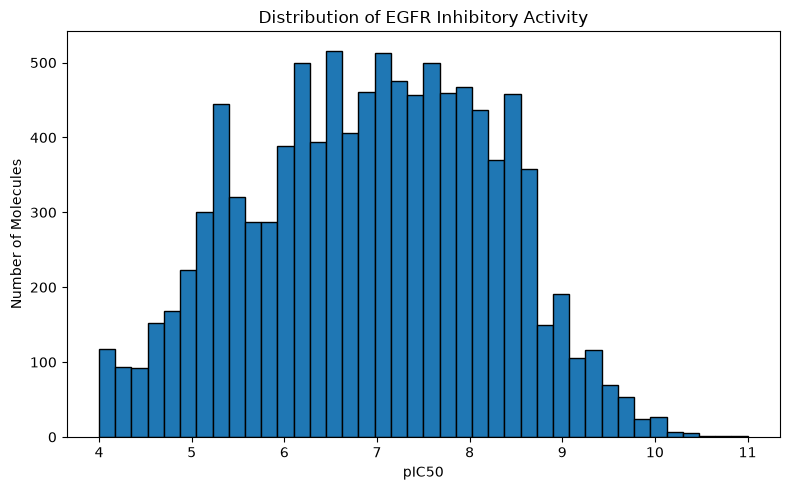

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    molecule_activity["pIC50"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("pIC50")
plt.ylabel("Number of Molecules")
plt.title("Distribution of EGFR Inhibitory Activity")

plt.tight_layout()
plt.show()

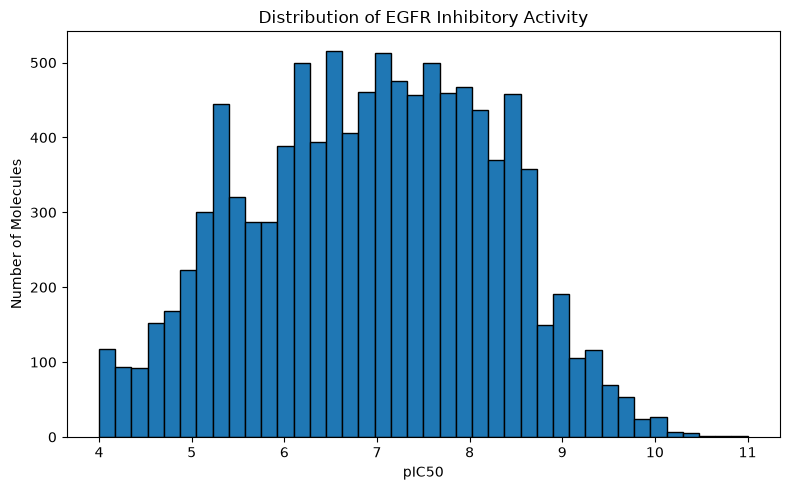

Figure saved to: /Users/gracescanlan/Desktop/egfr-ml-drug-discovery/figures/pic50_distribution.png


In [22]:
figure_path = PROJECT_ROOT / "figures" / "pic50_distribution.png"

plt.figure(figsize=(8, 5))
plt.hist(
    molecule_activity["pIC50"],
    bins=40,
    edgecolor="black"
)

plt.xlabel("pIC50")
plt.ylabel("Number of Molecules")
plt.title("Distribution of EGFR Inhibitory Activity")
plt.tight_layout()

plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {figure_path}")

## Get molecular structures

### Check whether chEMBL 

In [23]:
structure_columns = [
    col for col in clean_df.columns
    if "smile" in col.lower()
    or "structure" in col.lower()
    or "canonical" in col.lower()
]

structure_columns

['canonical_smiles']

In [24]:
clean_df.columns.tolist()

['action_type',
 'activity_comment',
 'activity_id',
 'activity_properties',
 'assay_chembl_id',
 'assay_description',
 'assay_type',
 'assay_variant_accession',
 'assay_variant_mutation',
 'bao_endpoint',
 'bao_format',
 'bao_label',
 'canonical_smiles',
 'data_validity_comment',
 'data_validity_description',
 'document_chembl_id',
 'document_journal',
 'document_year',
 'ligand_efficiency',
 'modality',
 'molecule_chembl_id',
 'molecule_pref_name',
 'parent_molecule_chembl_id',
 'pchembl_value',
 'potential_duplicate',
 'qudt_units',
 'record_id',
 'relation',
 'src_id',
 'standard_flag',
 'standard_relation',
 'standard_text_value',
 'standard_type',
 'standard_units',
 'standard_upper_value',
 'standard_value',
 'target_chembl_id',
 'target_organism',
 'target_pref_name',
 'target_tax_id',
 'text_value',
 'toid',
 'type',
 'units',
 'uo_units',
 'upper_value',
 'value']

## Add Molecular Structures

Canonical SMILES strings from ChEMBL were matched to the consolidated molecule-level activity dataset.

Each molecule should have one canonical SMILES representation that can later be converted into RDKit molecular descriptors and fingerprints.

In [25]:
smiles_df = (
    clean_df[
        ["molecule_chembl_id", "canonical_smiles"]
    ]
    .drop_duplicates(subset="molecule_chembl_id")
)

print("Unique molecules with SMILES records:", len(smiles_df))

smiles_df.head()

Unique molecules with SMILES records: 10398


,molecule_chembl_id,canonical_smiles
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...
1,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...
2,CHEMBL137635,CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12
5,CHEMBL77085,N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-]
6,CHEMBL443268,Cc1cc(C(=O)NCCN2CCOCC2)[nH]c1/C=C1\C(=O)N(C)c2...


### Merge SMILES into molecule_activity

In [26]:
molecule_activity = molecule_activity.merge(
    smiles_df,
    on="molecule_chembl_id",
    how="left"
)

print("Merged dataset shape:", molecule_activity.shape)

molecule_activity.head()

Merged dataset shape: (10398, 7)


,molecule_chembl_id,median_ic50_nM,n_measurements,min_ic50_nM,max_ic50_nM,pIC50,canonical_smiles
0,CHEMBL10,53000.0,2,10000.0,96000.0,4.275724,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...
1,CHEMBL1009,2880.0,1,2880.0,2880.0,5.540608,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O
2,CHEMBL101253,457.7,1,457.7,457.7,6.339419,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1
3,CHEMBL1016,3276.9,1,3276.9,3276.9,5.484537,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...
4,CHEMBL101683,7300.0,1,7300.0,7300.0,5.136677,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1


### Check missing SMILES

In [27]:
missing_smiles = molecule_activity["canonical_smiles"].isna().sum()

print("Total molecules:", len(molecule_activity))
print("Missing SMILES:", missing_smiles)
print(
    "Percent with SMILES:",
    round(
        100 * (1 - missing_smiles / len(molecule_activity)),
        2
    )
)

Total molecules: 10398
Missing SMILES: 17
Percent with SMILES: 99.84


### Check for blank strings 

In [28]:
blank_smiles = (
    molecule_activity["canonical_smiles"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Blank or missing SMILES:", blank_smiles)

Blank or missing SMILES: 17


### Remove Molecules Without Molecular Structures

Molecules without a canonical SMILES representation cannot be used for structure-based QSAR modeling because molecular descriptors and fingerprints cannot be calculated without a defined chemical structure.

Molecules with missing or blank canonical SMILES strings were therefore removed before RDKit structure validation.

In [29]:
structure_df = molecule_activity[
    molecule_activity["canonical_smiles"].notna()
    & molecule_activity["canonical_smiles"].str.strip().ne("")
].copy()

print("Molecules before SMILES filtering:", len(molecule_activity))
print("Molecules removed:", len(molecule_activity) - len(structure_df))
print("Molecules remaining:", len(structure_df))

Molecules before SMILES filtering: 10398
Molecules removed: 17
Molecules remaining: 10381


### Validate structures with RDKit

In [30]:
from rdkit import Chem

In [31]:
def is_valid_smiles(smiles):
    if pd.isna(smiles):
        return False

    mol = Chem.MolFromSmiles(smiles)

    return mol is not None

In [32]:
molecule_activity["valid_smiles"] = (
    molecule_activity["canonical_smiles"]
    .apply(is_valid_smiles)
)

molecule_activity["valid_smiles"].value_counts(dropna=False)

valid_smiles
True     10381
False       17
Name: count, dtype: int64

### Create the structure-ready dataset

In [33]:
structure_df = molecule_activity[
    molecule_activity["valid_smiles"]
].copy()

print("Molecules before structure validation:",
      len(molecule_activity))

print("Molecules after structure validation:",
      len(structure_df))

Molecules before structure validation: 10398
Molecules after structure validation: 10381


In [34]:
structure_df[
    [
        "molecule_chembl_id",
        "canonical_smiles",
        "median_ic50_nM",
        "pIC50"
    ]
].head(10)

,molecule_chembl_id,canonical_smiles,median_ic50_nM,pIC50
0,CHEMBL10,C[S+]([O-])c1ccc(-c2nc(-c3ccc(F)cc3)c(-c3ccncc...,53000.0,4.275724
1,CHEMBL1009,N[C@@H](Cc1ccc(O)c(O)c1)C(=O)O,2880.0,5.540608
2,CHEMBL101253,Clc1ccc(Nc2nnc(Cc3ccncc3)c3ccccc23)cc1,457.7,6.339419
3,CHEMBL1016,CCOc1nc2cccc(C(=O)O)c2n1Cc1ccc(-c2ccccc2-c2nnn...,3276.9,5.484537
4,CHEMBL101683,O=C(Nc1ccc(Cl)cc1)c1ccccc1NCc1ccncc1,7300.0,5.136677
5,CHEMBL102726,c1ccc(CNc2ncnc3ccccc23)cc1,320.0,6.494850
6,CHEMBL103552,O=C(O)c1cc(N(Cc2ccccc2O)Cc2cc(O)ccc2O)ccc1O,4100.0,5.387216
7,CHEMBL103667,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...,3800.0,5.420216
8,CHEMBL103860,O=C(O)c1cc(CCc2cc(O)ccc2O)ccc1O,3300.0,5.481486
9,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,69421.0,4.158509


In [35]:
processed_path = (
    PROCESSED_DATA_DIR /
    "egfr_molecule_activity_with_smiles.csv"
)

structure_df.to_csv(
    processed_path,
    index=False
)

print(f"Saved to:\n{processed_path}")

Saved to:
/Users/gracescanlan/Desktop/egfr-ml-drug-discovery/data/processed/egfr_molecule_activity_with_smiles.csv
